In [1]:
import cv2
import numpy as np
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt


In [2]:
def scale_pixels(img, mode=None):
    """
    Select a pixel scaling technique

    Args:
        mode: (string) pixel scaling technique
          rescale    :  stretch the pixel intensities so to fill the 
                        range from 0 to 1 (float64)
          center     :  enforce zero mean, unit variance (float64)
          grayscale  :  stretch the pixel intensities so to fill the 
                        range from 0 to 255 (uint8)

    Returns:
        A numpy array (either float64 or uint8) of the scaled image.
    """
    img = img.astype(np.float64)
    if mode == None:
        return img
    elif mode == "rescale":
        return ((img - img.min()) / (img.max() - img.min()) + 1e-16).astype(np.float64)
    elif mode == "center":
        return ((img - img.mean()) / (img.std())).astype(np.float64)
    elif mode == "grayscale":
        return (255 * (img - img.min()) / (img.max() - img.min()) + 1e-16).astype(
            np.uint8
        )
        
def score_ssim(img1, img2):
    """
    Compute the mean structural similarity index between two images

    Args:
        img1, img2: (ndarray) images

    Return:
        1 - the mean structural similarity index (i.e. ΔSSIM)
    """

    #data_range = 255  # Dynamic range of pixel values in typical images

    img1 = scale_pixels(img1, mode="rescale")  # You need to define the scale_pixels function
    img2 = scale_pixels(img2, mode="rescale")
    im_max, im_min = max(img1.max(), img2.max()), min(img1.min(), img2.min())
    return 1 - ssim(img1, img2, data_range=im_max - im_min)  # You need to import the ssim function

   
    #ssim(img1, img2, data_range=255, full=True, win_size=1, use_sample_covariance=False)


In [5]:
# Load the image arrays from the jpgs
color_image_exp = cv2.imread('denoised_13_crop.png')
color_image_incostem = cv2.imread('Incostem_img.png')
color_image_dr_probe = cv2.imread('250x250x30_Stem_crop.png')



# Convert to grayscale using luminance formula
exp_img = cv2.cvtColor(color_image_exp, cv2.COLOR_BGR2GRAY)
incostem_img = cv2.cvtColor(color_image_incostem, cv2.COLOR_BGR2GRAY)
dr_probe_img = cv2.cvtColor(color_image_dr_probe, cv2.COLOR_BGR2GRAY)



# Check if they are the same size
print(exp_img.shape)
print(incostem_img.shape)
print(dr_probe_img.shape)




(230, 330)
(480, 640)
(416, 429)


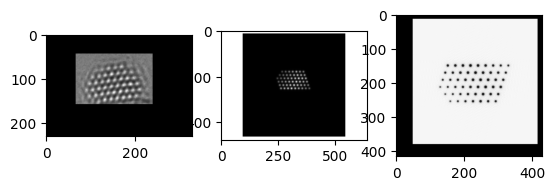

In [6]:
# view the initial images 
f, axes = plt.subplots(1, 3)
axes[0].imshow(exp_img, cmap='gray')
axes[1].imshow(incostem_img, cmap='gray')
axes[2].imshow(dr_probe_img, cmap='gray')
plt.show()

### CK: Here the experimental image is not full w.r.t all pixels. There is some black space that we need to remove. 

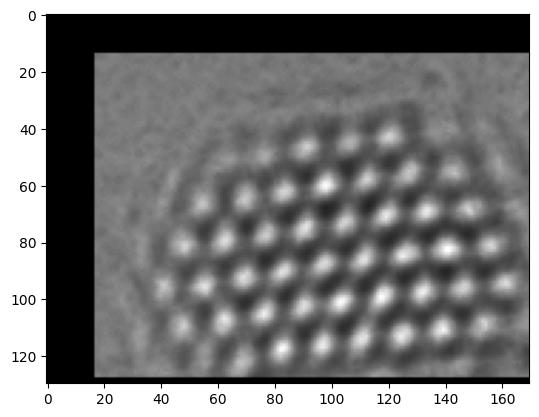

In [7]:
exp_x_start, exp_x_end = 30, 160
exp_y_start, exp_y_end = 50, 220
crp_exp_img = exp_img[exp_x_start:exp_x_end, exp_y_start:exp_y_end]
plt.imshow(crp_exp_img, cmap='gray'); plt.show()

### CK: adjust the inds so that the image is cropped leaving the black space

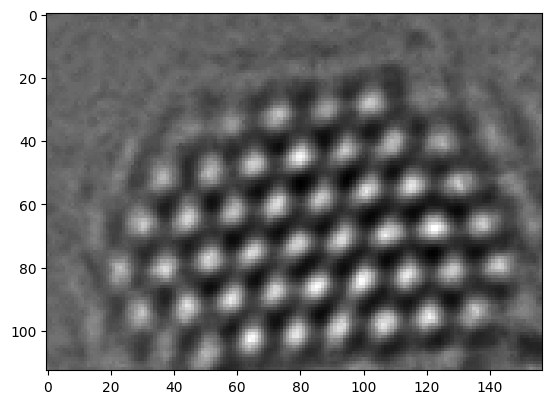

In [9]:
exp_x_start, exp_x_end = 30+15, 160-2
exp_y_start, exp_y_end = 50+18, 220+5
crp_exp_img = exp_img[exp_x_start:exp_x_end, exp_y_start:exp_y_end]
plt.imshow(crp_exp_img, cmap='gray'); plt.show()

#### CK: Now the image got a bit of contrast because the black region is removed and now the pixel values are more relative to within the actual image. 

#### Now, just for the aesthetics, lets move the Pt nanocrystal to the center. 

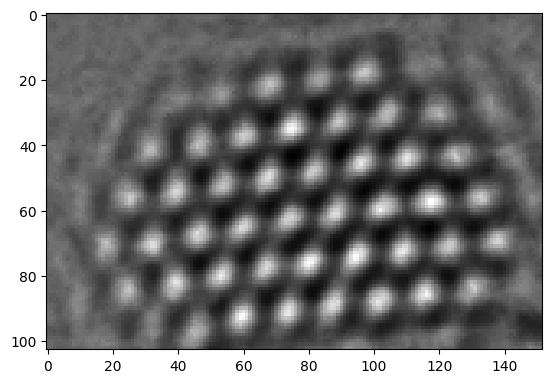

Cropped size of exp. image:  (103, 152)


In [14]:
exp_x_start, exp_x_end = 30+15+10, 160-2
exp_y_start, exp_y_end = 50+18+5, 220+5
crp_exp_img = exp_img[exp_x_start:exp_x_end, exp_y_start:exp_y_end]
plt.imshow(crp_exp_img, cmap='gray'); plt.show()

print ("Cropped size of exp. image: ", crp_exp_img.shape)

#### CK: Next, we need to crop the incostem simulation and then drprobe simulation images similarly. And then, apply cv2.resize to make sure the pixels are same in all three images. 

First crop by eyeballing the pixels in the earlier plot in cell [4]

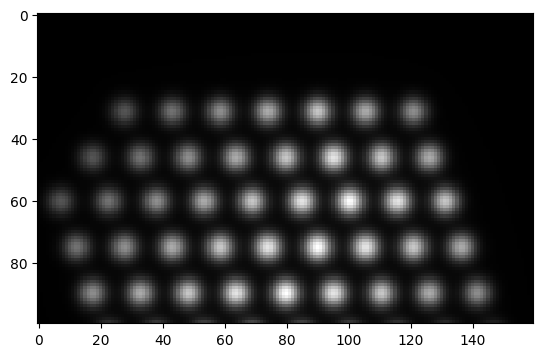

In [16]:
incstm_x_start, incstm_x_end = 150, 250
incstm_y_start, incstm_y_end = 240, 400
crp_incstm_img = incostem_img[incstm_x_start:incstm_x_end, incstm_y_start:incstm_y_end]
plt.imshow(crp_incstm_img, cmap='gray'); plt.show()

In [ ]:
#### CK: Make it better and then resize

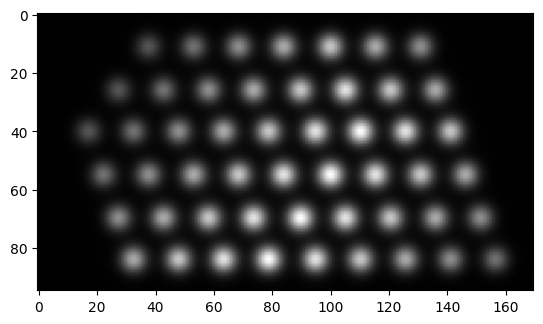

In [17]:
incstm_x_start, incstm_x_end = 150+20, 250+15
incstm_y_start, incstm_y_end = 240-10, 400
crp_incstm_img = incostem_img[incstm_x_start:incstm_x_end, incstm_y_start:incstm_y_end]
plt.imshow(crp_incstm_img, cmap='gray'); plt.show()

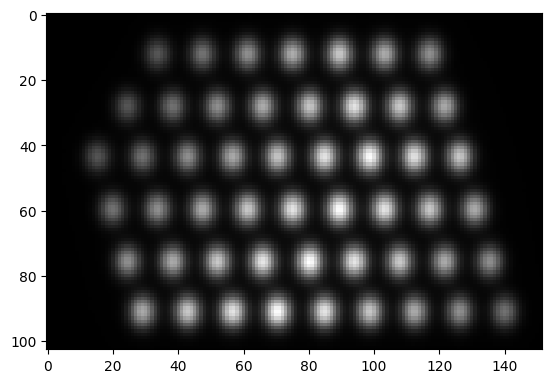

(103, 152) (103, 152)
0.8911045217287538


In [21]:
# Assuming these are the dimensions you want to use for resizing
exp_img_nx = crp_exp_img.shape[0]
incostem_n_x = crp_incstm_img.shape[0]

exp_img_ny = crp_exp_img.shape[1]
incostem_n_y = crp_incstm_img.shape[1]


new_x_I = int(exp_img_nx)
new_y_I = int(exp_img_ny)


# Resize the incostem_img
incostem_img = cv2.resize(crp_incstm_img, (new_y_I,new_x_I))

plt.imshow(incostem_img, cmap='gray'); plt.show()
print (crp_exp_img.shape, incostem_img.shape)
print (score_ssim(crp_exp_img, incostem_img))

In [306]:
# Crop the incostem_img and dr_probe_img to make them the same size as the experimental image
x_i, x_j = 30, 350  # Define your cropping coordinates for incostem_img
y_i, y_j = 50, 410
dr_probe_img = dr_probe_img[x_i:x_j, y_i:y_j]

print(dr_probe_img.shape)

x_n, x_m = 100, 350  # Define your cropping coordinates for dr_probe_img
y_n, y_m = 150, 510
incostem_img = incostem_img[x_n:x_m, y_n:y_m]


print(incostem_img.shape)

(320, 360)
(250, 360)


In [307]:
exp_img_nx = exp_img.shape[0]
dr_probe_n_x = dr_probe_img.shape[0]

exp_img_ny = exp_img.shape[1]
dr_probe_n_y = dr_probe_img.shape[1]

new_x_P = int(dr_probe_n_x * (exp_img_nx / dr_probe_n_x))
new_y_P = int(dr_probe_n_y * (exp_img_ny / dr_probe_n_y))

# Resize the incostem_img
dr_probe_img = cv2.resize(dr_probe_img, (new_y_P, new_x_P))

# Check if they are the same size
print(exp_img.shape)
print(dr_probe_img.shape)

(230, 330)
(230, 330)


In [308]:
# Assuming these are the dimensions you want to use for resizing


exp_img_nx = exp_img.shape[0]
incostem_n_x = incostem_img.shape[0]

exp_img_ny = exp_img.shape[1]
incostem_n_y = incostem_img.shape[1]


new_x_I = int(exp_img_nx)
new_y_I = int(exp_img_ny)


# Resize the incostem_img
incostem_img = cv2.resize(incostem_img, (new_y_I,new_x_I))


# Check if they are the same size
#print(exp_img.shape)
print(incostem_img.shape)

(230, 330)


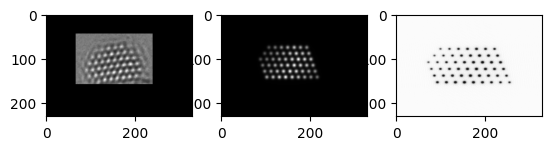

In [309]:
# Get the ssim scores
incostem_score = score_ssim(exp_img, incostem_img)
dr_probe_score = score_ssim(exp_img, dr_probe_img)

# Plot the images
f, axes = plt.subplots(1, 3)
axes[0].imshow(exp_img, cmap='gray')
axes[1].imshow(incostem_img, cmap='gray')
axes[2].imshow(dr_probe_img, cmap='gray')
plt.show()
